In [1]:
import gdsfactory as gf
gf.gpdk.get_generic_pdk().activate()

In [2]:
# --- Parameters (µm) ---
WG_WIDTH = 0.8
PITCH = 127.0
RADIUS = (PITCH / 2) - 5.8   # Euler bend to hit ~127 µm vertical spacing
STRAIGHT_LEN = 5000
GAP = 127

# Etch sweep
ETCH_LENGTHS = [100, 300, 500, 800, 1500, 3000]
ETCH_WIDTHS = [10, 30, 50]
ETCH_GAPS = [0.4, 0.8, 1.5, 3]

# Layers
L_WG, L_BOX = (1, 0), (2, 0)

In [3]:
xs = gf.cross_section.strip(width=WG_WIDTH, layer=L_WG)

def loopback(straight_len: float, radius: float, offset_y: float = 0, angle: int = 180) -> gf.Component:
    p = gf.path.Path()
    p += gf.path.straight(straight_len)
    p += gf.path.euler(radius=radius, angle=angle)
    p += gf.path.straight(straight_len)
    loop = p.extrude(cross_section=xs)
    c = gf.Component()
    r = c << loop
    r.move((0, offset_y))
    c.add_port("o1", port=r.ports["o1"])
    c.add_port("o2", port=r.ports["o2"])
    return c

@gf.cell
def unit(trench_l: float, trench_w: float, etch_gap: float) -> gf.Component:
    c = gf.Component()
    x0 = STRAIGHT_LEN - 500 - trench_l
    t1 = c.add_ref(gf.components.rectangle(size=(trench_l, trench_w), layer=L_BOX))
    t2 = c.add_ref(gf.components.rectangle(size=(trench_l, trench_w), layer=L_BOX))
    t1.move((x0, WG_WIDTH / 2 + etch_gap))
    t2.move((x0, -WG_WIDTH / 2 - etch_gap - trench_w))
    c << loopback(STRAIGHT_LEN, RADIUS, 0)
    c << loopback(STRAIGHT_LEN, 3 * RADIUS, -GAP)
    return c

In [4]:
def spacing_for_radius(R, xs=None):
    xs = xs or gf.cross_section.strip(width=WG_WIDTH, layer=L_WG)
    p = gf.path.Path()
    p += gf.path.straight(100) + gf.path.euler(radius=R, angle=180) + gf.path.straight(100)
    c = p.extrude(cross_section=xs)
    return abs(c.ports["o2"].center[1] - c.ports["o1"].center[1])

In [5]:
# spacing_for_radius(R) for radius calibration; use product(ETCH_LENGTHS, ETCH_WIDTHS, ETCH_GAPS) to customize combos


Total: 20


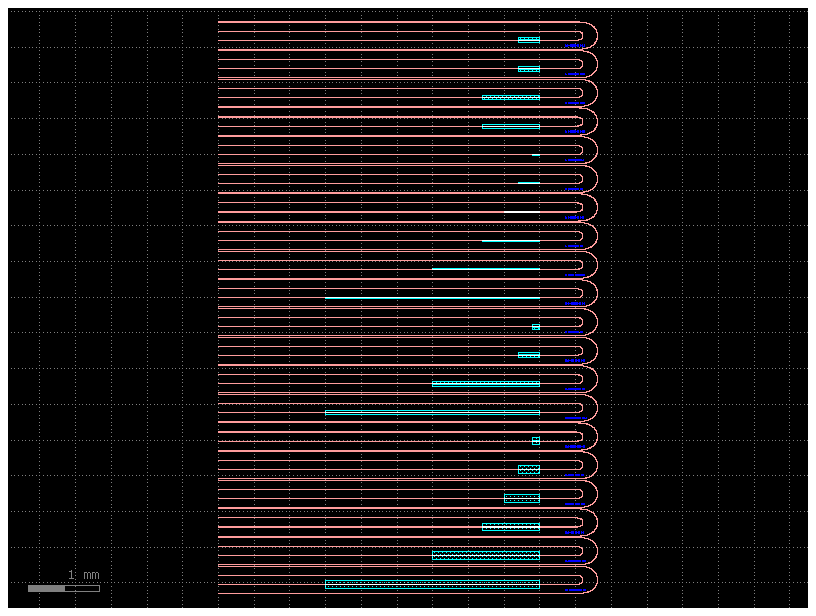

In [6]:
# Build all combos: special (L=300,800 × W=30 × G=0.4,0.8) + sweep (other L×W, alternating G=1.5/3)
SPECIAL_LW = [(300, 30), (800, 30)]
SKIP_LW = [(500, 30), (800, 30)]  # exclude from main sweep (in special)

special = [(L, W, G) for L, W in SPECIAL_LW for G in [0.4, 0.8]]
sweep = []
for j, W in enumerate(ETCH_WIDTHS):
    for i, L in enumerate(ETCH_LENGTHS):
        if (L, W) in SKIP_LW:
            continue
        G = ETCH_GAPS[2] if (i + j) % 2 == 0 else ETCH_GAPS[3]
        sweep.append((L, W, G))
combos = special + sweep

# Place and label
c = gf.Component("loopbacks")
LBL = (10, 0)
for n, (L, W, G) in enumerate(combos, start=1):
    sub = c << unit(L, W, G)
    sub.move((0, -3 * GAP * n - 20 * n))
    txt = c << gf.components.text(f"{n}: L={L} W={W} G={G}", size=20, layer=LBL)
    txt.move((sub.x + 2200, sub.y - 150))

c.plot()
print("Total:", len(combos))


In [7]:
c.show()  # needs klive running in KLayout (green icon)

# Fallback: write GDS and open manually in KLayout
c.write_gds("loopback_chip.gds")
print("Saved loopback_chip.gds")

2026-02-07 20:42:56.203 | INFO     | kfactory.kcell:show:3979 - klive v0.4.1: Opened file 'C:\Users\prava\AppData\Local\Temp\1973785454.oas'


Saved loopback_chip.gds
